
Loading UCI Metro Interstate Traffic Volume hourly data...
Total hourly rows in Metro CSV:       48204
Complete daily functional curves:     1214
Pre-forecast daily observations:      1207
Forecast/test observations:           7
Forecast/test date range:             2018-09-24 to 2018-09-30
Functional curves shape:              (1214, 24)
Nonfunctional matrix shape:           (1214, 49)
Functional grid points:               24
Nonfunctional variables per day:      49

Selected tuned Hybrid settings
Hybrid shared latent dimension:       7
Functional feature dimension f:       16
Hybrid B-spline basis size:           24
Hybrid hidden width:                  192
Hybrid nonfunctional hidden width:    192
Hybrid nonfunctional loss weight:     0.7
Hybrid smooth lambda:                 0.0002
Hybrid latent smooth lambda:          0.0015
Hybrid learning rate:                 0.00065
Checkpoint warmup starts at epoch:    50
HPCA score dimension:      7


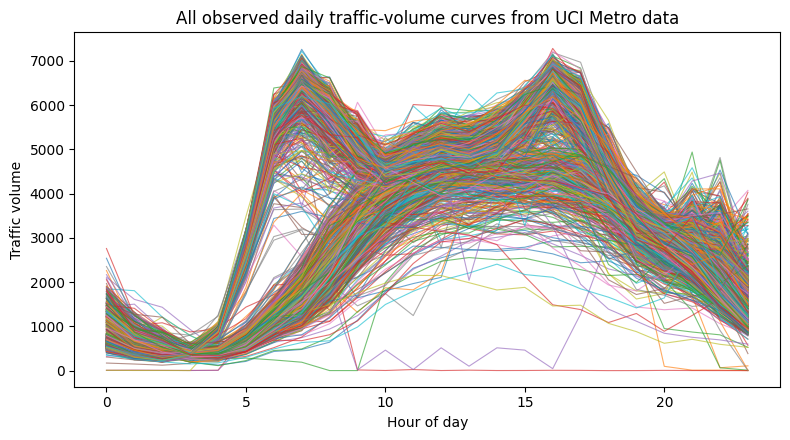


Training tuned Hybrid AE with chronological validation split...
Epoch    1/900  | train_func=0.850395 | val_func=0.202868 | train_nonfunc=0.948798 | val_nonfunc=0.627371
Epoch   50/900* | train_func=0.247953 | val_func=0.069657 | train_nonfunc=0.225765 | val_nonfunc=0.281843
Epoch  100/900* | train_func=0.101268 | val_func=0.095070 | train_nonfunc=0.096179 | val_nonfunc=0.241941
Epoch  150/900* | train_func=0.080285 | val_func=0.076497 | train_nonfunc=0.075542 | val_nonfunc=0.244469
Epoch  200/900* | train_func=0.064255 | val_func=0.088546 | train_nonfunc=0.059112 | val_nonfunc=0.228489
Epoch  250/900* | train_func=0.073580 | val_func=0.098986 | train_nonfunc=0.054146 | val_nonfunc=0.241449
Epoch  300/900* | train_func=0.067388 | val_func=0.107281 | train_nonfunc=0.057153 | val_nonfunc=0.247558
Early stopping at epoch 318. Best eligible epoch=138, best validation hybrid_unweighted=0.304696


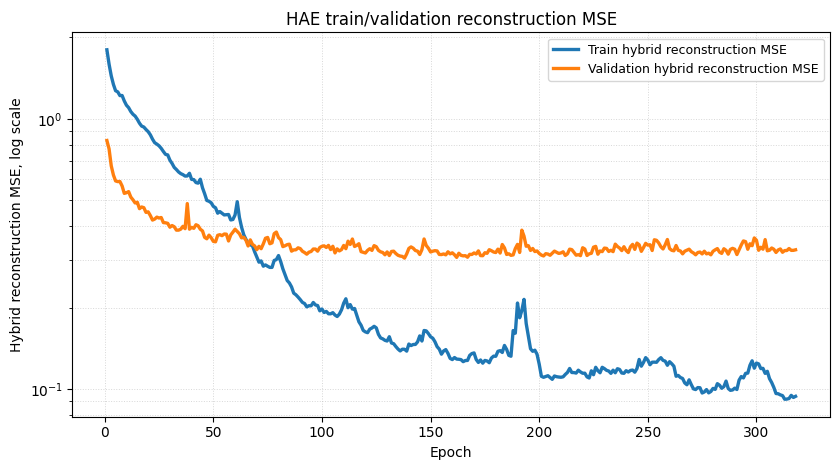


HAE reconstruction MSE on full pre-forecast block
Functional standardized log1p-count scale: 0.068220
Nonfunctional standardized scale:          0.092030

Fitting external VAR model to tuned HAE latent scores...
HAE score model: VAR(7)
HAE score AIC:   -3.725502

Fitting concatenated FPCA/PCA baseline...
HPCA score model: VAR(12)
HPCA score AIC:   -5.642082
Combined PCA explained variance with K=7: 0.5595

HPCA reconstruction MSE on full pre-forecast block
Functional standardized log1p-count scale: 0.187828
Nonfunctional standardized scale:          0.510260

Forecasting results
                Target     Method  Functional_MSE_count  Functional_RMSE_count  Functional_relMSE_count  Nonfunctional_MSE_scaled  Nonfunctional_RMSE_scaled  Nonfunctional_relMSE_scaled
Held-out observed data  HAE + VAR         210635.708030             458.950660                 0.013653                  0.352354                   0.593595                     0.785131
Held-out observed data HPCA + VAR        

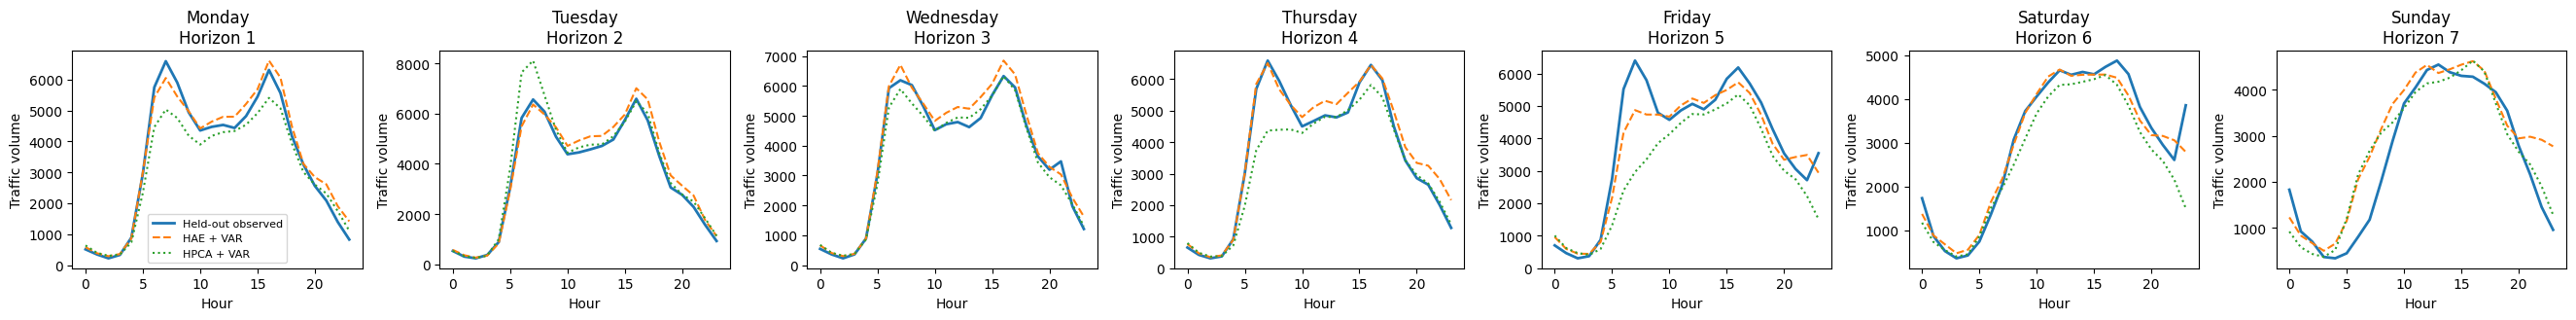

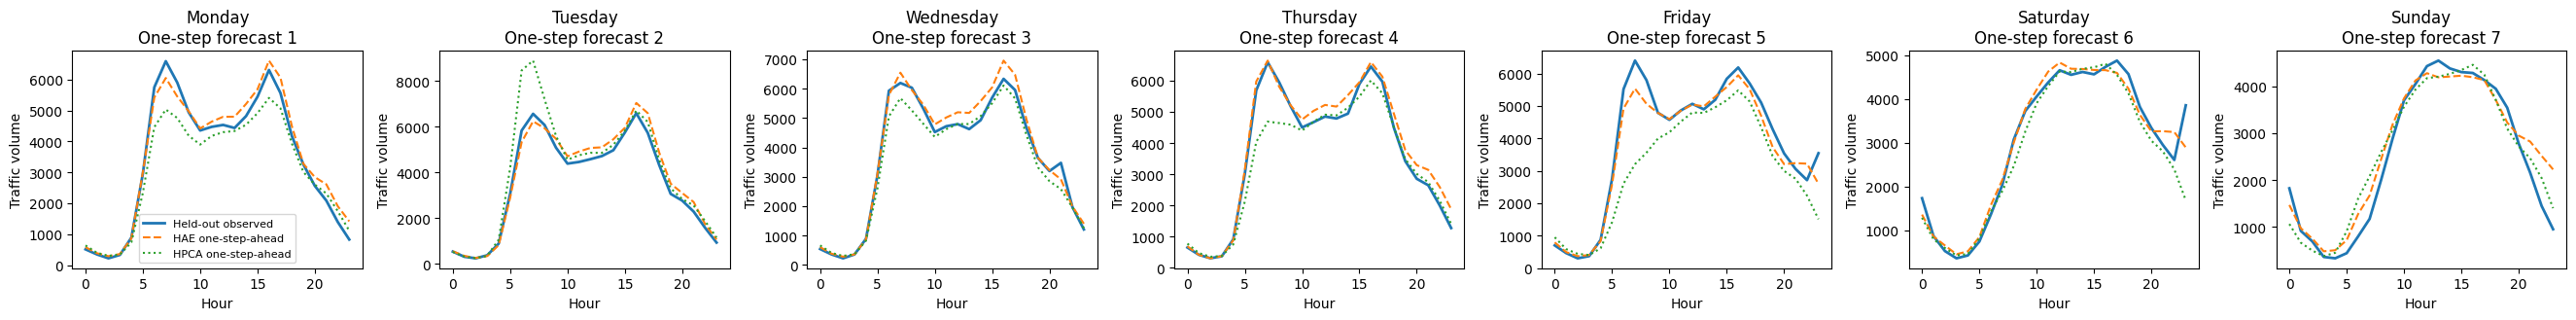


One-step-ahead forecasting results
                      Target     Method  Functional_MSE_count  Functional_RMSE_count  Functional_relMSE_count  Nonfunctional_MSE_scaled  Nonfunctional_RMSE_scaled  Nonfunctional_relMSE_scaled
One-step-ahead held-out data  HAE + VAR         125049.324083             353.623139                 0.008106                  0.349089                   0.590838                     0.777855
One-step-ahead held-out data HPCA + VAR         488814.788049             699.152907                 0.031685                  0.384878                   0.620385                     0.857601

Winner check on final held-out days
Functional curves: Hybrid beats FPCA/PCA by 74.42% MSE.
Nonfunctional vectors: Hybrid beats FPCA/PCA by 9.30% MSE.


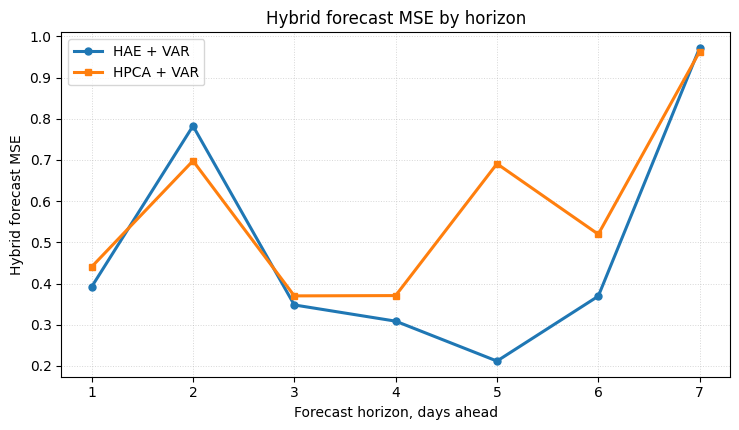


Hybrid forecast MSE by horizon
 horizon  hybrid_functional_mse_stdlog  hybrid_nonfunctional_mse_scaled  hybrid_total_mse  baseline_functional_mse_stdlog  baseline_nonfunctional_mse_scaled  baseline_total_mse
       1                      0.141464                         0.250594          0.392058                        0.142310                           0.298232            0.440541
       2                      0.094828                         0.687644          0.782472                        0.078224                           0.619595            0.697818
       3                      0.068516                         0.279492          0.348008                        0.099715                           0.270290            0.370005
       4                      0.097571                         0.211105          0.308676                        0.077209                           0.293525            0.370734
       5                      0.069858                         0.141945          0.

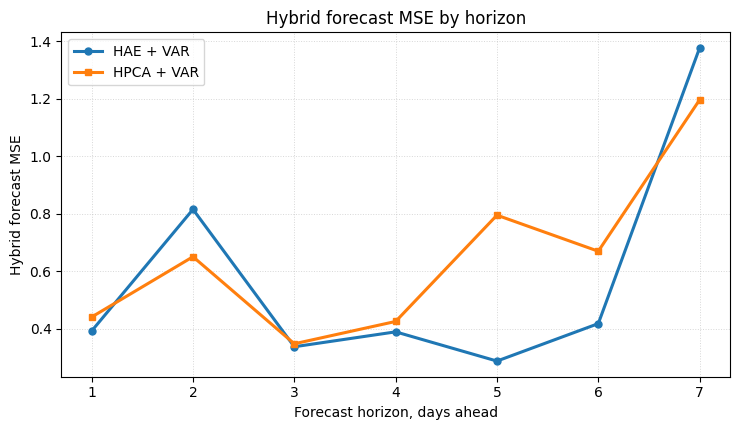


Hybrid forecast MSE by horizon
 horizon  hybrid_functional_mse_stdlog  hybrid_nonfunctional_mse_scaled  hybrid_total_mse  baseline_functional_mse_stdlog  baseline_nonfunctional_mse_scaled  baseline_total_mse
       1                      0.141464                         0.250594          0.392058                        0.142310                           0.298232            0.440541
       2                      0.106849                         0.708451          0.815300                        0.044074                           0.606317            0.650391
       3                      0.100681                         0.236414          0.337095                        0.083101                           0.264342            0.347444
       4                      0.157498                         0.231443          0.388941                        0.110797                           0.314326            0.425123
       5                      0.152547                         0.134716          0.

In [ ]:
from __future__ import annotations

import copy
import random
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.interpolate import BSpline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from torch import optim
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Config
# ============================================================

@dataclass
class Config:
    csv_path: Optional[str] = r"D:\Marquette\FAE Codes\HAE\metro_interstate_traffic_volume.zip"

    # UCI static zip URL. 
    data_url: str = (
        "https://archive.ics.uci.edu/static/public/492/"
        "metro+interstate+traffic+volume.zip"
    )
    data_dir: str = "data"

    # Forecast last L complete days.
    forecast_horizon: int = 7

    # One day = one 24-hour traffic-volume curve.
    n_grid: int = 24

    latent_dim: int = 7
    functional_feature_dim: int = 16
    n_basis: int = 24
    hidden_width: int = 192
    nonfunctional_hidden_width: int = 192

    smooth_lambda: float = 2.0e-4
    latent_smooth_lambda: float = 1.5e-3


    nonfunctional_loss_weight: float = 0.70
    selection_nonfunctional_weight: float = 0.05

    checkpoint_start_epoch: int = 50
    early_stopping_patience: int = 180

    early_stopping_metric: str = "hybrid_unweighted"

    refit_final_on_full_preforecast: bool = False

    # Training.
    epochs: int = 900
    batch_size: int = 64
    learning_rate: float = 6.5e-4
    weight_decay: float = 2.5e-5
    validation_fraction: float = 0.15


    early_stopping_min_delta: float = 1.0e-7
    gradient_clip_norm: float = 5.0
    shuffle_batches: bool = False


    final_refit_min_epochs: int = 260
    final_refit_max_epochs: int = 420
    final_refit_epoch_multiplier: float = 1.10

    # Baseline: keep same K as Hybrid 
    baseline_latent_dim: Optional[int] = None

    # AR/VAR lag search.
    max_ar_lags: int = 21

    # Reproducibility.
    seed: int = 776

    # Plotting.
    n_curve_plot: int = 50
    moving_average_window: int = 9
    plot_nonfunctional_feature_map: bool = True


CFG = Config()


# ============================================================
# Utilities
# ============================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(1)


def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def mse(pred, truth) -> float:
    pred = to_numpy(pred)
    truth = to_numpy(truth)
    return float(np.mean((pred - truth) ** 2))


def rmse(pred, truth) -> float:
    return float(np.sqrt(mse(pred, truth)))


def relative_mse(pred, truth) -> float:
    pred = to_numpy(pred)
    truth = to_numpy(truth)
    denom = float(np.mean(truth ** 2))
    if denom <= 1.0e-12:
        return float("nan")
    return float(np.mean((pred - truth) ** 2) / denom)


def inverse_standardized_log_count_transform(
    x_standardized_log: np.ndarray,
    x_log_scaler: StandardScaler,
) -> np.ndarray:
    """
    Convert standardized log1p traffic-volume curves back to nonnegative counts.
    """
    x_log = x_log_scaler.inverse_transform(np.asarray(x_standardized_log, dtype=np.float64))
    x_count = np.expm1(x_log)
    return np.clip(x_count, 0.0, None)


# ============================================================
# Data loading and preprocessing
# ============================================================

def load_hourly_traffic_dataframe(cfg: Config) -> pd.DataFrame:
    """
    Load the UCI Metro Interstate Traffic Volume CSV.

    Expected raw columns:
        holiday, temp, rain_1h, snow_1h, clouds_all, weather_main,
        weather_description, date_time, traffic_volume
    """
    if cfg.csv_path is not None:
        path = Path(cfg.csv_path)
        if not path.exists():
            raise FileNotFoundError(f"csv_path does not exist: {path}")

        if path.suffix.lower() == ".zip":
            with zipfile.ZipFile(path, "r") as zf:
                csv_members = [
                    name for name in zf.namelist()
                    if name.lower().endswith((".csv", ".csv.gz"))
                ]
                if not csv_members:
                    raise FileNotFoundError("Could not find a CSV file inside the zip file.")

                member = csv_members[0]
                with zf.open(member) as f:
                    if member.lower().endswith(".gz"):
                        import gzip
                        with gzip.open(f, mode="rt") as g:
                            df = pd.read_csv(g)
                    else:
                        df = pd.read_csv(f)
        else:
            df = pd.read_csv(path, compression="infer")

    required = {
        "holiday", "temp", "rain_1h", "snow_1h", "clouds_all",
        "weather_main", "weather_description", "date_time", "traffic_volume",
    }
    missing = sorted(required.difference(df.columns))
    if missing:
        raise ValueError(f"Missing required columns in Metro traffic CSV: {missing}")

    df = df.copy()
    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time").reset_index(drop=True)

    df["date"] = df["date_time"].dt.floor("D")
    df["hr"] = df["date_time"].dt.hour.astype(int)

    return df


def safe_mode_value(x: pd.Series):
    mode = x.dropna().mode()
    if len(mode) == 0:
        return np.nan
    return mode.iloc[0]


def one_hot_reindex(values: pd.Series, prefix: str, categories: List[str]) -> pd.DataFrame:
    values = values.fillna("Missing").astype(str)
    dummies = pd.get_dummies(values, prefix=prefix)
    expected_cols = [f"{prefix}_{cat}" for cat in categories]
    dummies = dummies.reindex(columns=expected_cols, fill_value=0.0)
    return dummies.astype(np.float32)


def build_daily_functional_and_nonfunctional_data(
    df_raw: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str], pd.DatetimeIndex]:
    """
    Build one functional curve and one nonfunctional vector per complete day.

    Returns
    -------
    hour_grid:
        Array of 24 hourly grid points, 0 through 23.
    x_counts:
        Functional matrix [n_days, 24], daily traffic-volume curves.
    y_raw:
        Nonfunctional matrix [n_days, n_features], daily weather/calendar features.
    y_feature_names:
        Names of engineered nonfunctional variables.
    dates:
        Dates corresponding to rows.
    """
    hour_grid = np.arange(24, dtype=np.float32)

    # Collapse possible duplicate date_time rows caused by multiple weather descriptions.
    agg = {
        "traffic_volume": "mean",
        "temp": "mean",
        "rain_1h": "mean",
        "snow_1h": "mean",
        "clouds_all": "mean",
        "holiday": safe_mode_value,
        "weather_main": safe_mode_value,
        "weather_description": safe_mode_value,
    }

    df_hour = (
        df_raw
        .groupby(["date", "hr"], as_index=False)
        .agg(agg)
        .sort_values(["date", "hr"])
        .reset_index(drop=True)
    )

    daily_curve = df_hour.pivot_table(
        index="date",
        columns="hr",
        values="traffic_volume",
        aggfunc="mean",
    )

    daily_curve = daily_curve.reindex(columns=range(24))
    daily_curve = daily_curve.dropna(axis=0)

    dates = pd.DatetimeIndex(daily_curve.index)
    x_counts = daily_curve.to_numpy(dtype=np.float32)

    df_complete = df_hour[df_hour["date"].isin(dates)].copy()
    grouped = df_complete.groupby("date")

    y_parts = []

    # Calendar features.
    calendar = pd.DataFrame(index=dates)
    calendar["is_holiday"] = (
        grouped["holiday"].agg(safe_mode_value).reindex(dates).fillna("None").astype(str) != "None"
    ).astype(float)
    calendar["is_weekend"] = (dates.dayofweek >= 5).astype(float)
    calendar["year_index"] = (dates.year - dates.year.min()).astype(float)
    calendar["month_sin"] = np.sin(2.0 * np.pi * dates.month / 12.0)
    calendar["month_cos"] = np.cos(2.0 * np.pi * dates.month / 12.0)
    calendar["weekday_sin"] = np.sin(2.0 * np.pi * dates.dayofweek / 7.0)
    calendar["weekday_cos"] = np.cos(2.0 * np.pi * dates.dayofweek / 7.0)
    calendar["doy_sin"] = np.sin(2.0 * np.pi * dates.dayofyear / 365.25)
    calendar["doy_cos"] = np.cos(2.0 * np.pi * dates.dayofyear / 365.25)
    y_parts.append(calendar.astype(np.float32))

    # Continuous daily weather summaries.
    cont = pd.DataFrame(index=dates)
    for col in ["temp", "rain_1h", "snow_1h", "clouds_all"]:
        cont[f"{col}_mean"] = grouped[col].mean().reindex(dates)
        cont[f"{col}_min"] = grouped[col].min().reindex(dates)
        cont[f"{col}_max"] = grouped[col].max().reindex(dates)
        cont[f"{col}_std"] = grouped[col].std().reindex(dates).fillna(0.0)

    cont["rain_any"] = (grouped["rain_1h"].max().reindex(dates).fillna(0.0) > 0).astype(float)
    cont["snow_any"] = (grouped["snow_1h"].max().reindex(dates).fillna(0.0) > 0).astype(float)
    cont["temp_range"] = cont["temp_max"] - cont["temp_min"]
    cont["clouds_range"] = cont["clouds_all_max"] - cont["clouds_all_min"]
    y_parts.append(cont.astype(np.float32))

    # Common weather family one-hot features.
    weather_mode = grouped["weather_main"].agg(safe_mode_value).reindex(dates).fillna("Missing").astype(str)
    common_weather = [
        "Clear", "Clouds", "Rain", "Mist", "Snow",
        "Drizzle", "Haze", "Fog", "Thunderstorm",
    ]
    y_parts.append(one_hot_reindex(weather_mode, "weather", common_weather))

    # Named holiday one-hot features, excluding None.
    holiday_mode = grouped["holiday"].agg(safe_mode_value).reindex(dates).fillna("None").astype(str)
    holiday_categories = sorted([x for x in holiday_mode.unique().tolist() if x != "None"])
    holiday_categories = holiday_categories[:12]
    if holiday_categories:
        y_parts.append(one_hot_reindex(holiday_mode, "holiday", holiday_categories))

    y_df = pd.concat(y_parts, axis=1)

    valid = ~y_df.isna().any(axis=1)
    if not valid.all():
        y_df = y_df.loc[valid]
        daily_curve = daily_curve.loc[y_df.index]
        dates = pd.DatetimeIndex(y_df.index)
        x_counts = daily_curve.to_numpy(dtype=np.float32)

    y_raw = y_df.to_numpy(dtype=np.float32)
    y_feature_names = list(y_df.columns)

    return hour_grid, x_counts, y_raw, y_feature_names, dates


# ============================================================
# B-spline basis
# ============================================================

def make_bspline_basis(
    t_grid: np.ndarray,
    n_basis: int,
    degree: int = 3,
) -> torch.Tensor:
    t_grid = np.asarray(t_grid, dtype=float)

    a = float(t_grid.min())
    b = float(t_grid.max())

    if n_basis <= degree:
        raise ValueError("n_basis must be larger than degree.")

    n_interior = n_basis - degree - 1

    if n_interior > 0:
        interior = np.linspace(a, b, n_interior + 2)[1:-1]
    else:
        interior = np.array([])

    knots = np.concatenate([
        np.repeat(a, degree + 1),
        interior,
        np.repeat(b, degree + 1),
    ])

    basis = []

    for i in range(n_basis):
        c = np.zeros(n_basis)
        c[i] = 1.0

        spline = BSpline(
            knots,
            c,
            degree,
            extrapolate=False,
        )

        values = spline(t_grid)

        values = np.nan_to_num(
            values,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        basis.append(values)

    return torch.tensor(
        np.vstack(basis),
        dtype=torch.float32,
    )


# ============================================================
# Hybrid AE model
# ============================================================

def tuned_mlp(widths: List[int], activation: nn.Module = nn.GELU) -> nn.Sequential:
    """
    Same stable MLP style as your successful tuning script.
    """
    layers: List[nn.Module] = []
    for i in range(len(widths) - 1):
        layers.append(nn.Linear(widths[i], widths[i + 1]))
        is_last = i == len(widths) - 2
        if not is_last:
            layers.append(nn.LayerNorm(widths[i + 1]))
            layers.append(activation())
    return nn.Sequential(*layers)


class HybridFAEAE(nn.Module):
    """
    Hybrid AE model

    Functional branch:
        24-hour traffic curve -> functional feature/scores f

    Shared latent encoder:
        concatenate [f, raw nonfunctional weather/calendar vector]
        -> shared latent vector h

    Decoding structure, matching the shared decoder architecture:
        h -> layer3 -> layer4 -> [B-spline coefficients, nonfunctional vector]

        The last decoder output layer has n_basis + n_nonfunctional nodes:
            [coef_1, ..., coef_Kb, y_1, ..., y_p]

        The first n_basis outputs are B-spline coefficients and are mapped
        through the fixed B-spline basis to reconstruct the T-grid functional curve.
        The remaining n_nonfunctional outputs reconstruct the nonfunctional vector.
    """

    def __init__(
        self,
        n_grid: int,
        n_nonfunctional: int,
        latent_dim: int,
        functional_feature_dim: int,
        hidden_width: int,
        nonfunctional_hidden_width: int,
        n_basis: int,
        basis: torch.Tensor,
    ):
        super().__init__()

        self.n_basis = n_basis
        self.n_nonfunctional = n_nonfunctional

        # Kept in the signature for minimal changes/backward compatibility with build_hybrid_model.
        # The decoder hidden layers are now shared, so hidden_width controls layer3/layer4.
        _ = nonfunctional_hidden_width

        # Feature layer for the functional observation. x_i(t) -> f_i.
        self.functional_feature_layer = tuned_mlp([
            n_grid,
            hidden_width,
            hidden_width,
            functional_feature_dim,
        ])

        # Stabilize the scale of f before concatenating it with already-standardized nonfunctionals.
        self.functional_feature_norm = nn.LayerNorm(functional_feature_dim)
        self.shared_input_norm = nn.LayerNorm(functional_feature_dim + n_nonfunctional)

        # [functional features f, raw nonfunctional variables y].
        self.shared_latent_encoder = tuned_mlp([
            functional_feature_dim + n_nonfunctional,
            hidden_width,
            hidden_width,
            latent_dim,
        ])

        # Shared decoder after the shared latent vector h.
        # This is the requested structure:
        #     h -> layer3 -> layer4 -> n_basis + n_nonfunctional
        # The final vector is split into:
        #     coef:  first n_basis entries, used for x_hat = coef @ basis
        #     y_hat: remaining n_nonfunctional entries
        self.shared_decoder_to_coef_and_nonfunc = tuned_mlp([
            latent_dim,
            hidden_width,
            hidden_width,
            n_basis + n_nonfunctional,
        ])

        self.register_buffer("basis", basis)

    def functional_features(self, x_func: torch.Tensor) -> torch.Tensor:
        """Return the functional feature/scores f before the shared latent layer."""
        f_func = self.functional_feature_layer(x_func)
        return self.functional_feature_norm(f_func)

    def encode(
        self,
        x_func: torch.Tensor,
        y_nonfunc: torch.Tensor,
    ) -> torch.Tensor:
        f_func = self.functional_features(x_func)
        shared_input = torch.cat([f_func, y_nonfunc], dim=1)
        shared_input = self.shared_input_norm(shared_input)
        h = self.shared_latent_encoder(shared_input)
        return h

    def decode_latent(self, h: torch.Tensor):
        decoder_out = self.shared_decoder_to_coef_and_nonfunc(h)
        coef = decoder_out[:, :self.n_basis]
        y_hat = decoder_out[:, self.n_basis:]
        x_hat = torch.matmul(coef, self.basis)
        return x_hat, coef, y_hat

    def forward(
        self,
        x_func: torch.Tensor,
        y_nonfunc: torch.Tensor,
    ):
        h = self.encode(x_func, y_nonfunc)
        x_hat, coef, y_hat = self.decode_latent(h)
        return x_hat, y_hat, h, coef

def build_hybrid_model(
    cfg: Config,
    n_grid: int,
    n_nonfunctional: int,
    s: np.ndarray,
    device: torch.device,
) -> HybridFAEAE:
    basis = make_bspline_basis(s, cfg.n_basis)

    return HybridFAEAE(
        n_grid=n_grid,
        n_nonfunctional=n_nonfunctional,
        latent_dim=cfg.latent_dim,
        functional_feature_dim=cfg.functional_feature_dim,
        hidden_width=cfg.hidden_width,
        nonfunctional_hidden_width=cfg.nonfunctional_hidden_width,
        n_basis=cfg.n_basis,
        basis=basis,
    ).to(device)


# ============================================================
# Splitting and losses
# ============================================================

def chronological_train_validation_split_two(
    x: np.ndarray,
    y: np.ndarray,
    validation_fraction: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    n_total = x.shape[0]

    n_val = int(round(validation_fraction * n_total))
    n_val = max(1, n_val)
    n_val = min(n_val, n_total - 1)

    x_train = x[:-n_val]
    x_val = x[-n_val:]

    y_train = y[:-n_val]
    y_val = y[-n_val:]

    return x_train, x_val, y_train, y_val


def hybrid_batch_losses(
    model: nn.Module,
    x_batch: torch.Tensor,
    y_batch: torch.Tensor,
    cfg: Config,
    mse_loss: nn.Module,
):
    """
    Autoencoder training loss.
    """
    x_hat, y_hat, h, coef = model(x_batch, y_batch)

    functional_recon = mse_loss(x_hat, x_batch)
    nonfunctional_recon = mse_loss(y_hat, y_batch)

    # Smooth functional B-spline coefficients.
    coef_second_diff = coef[:, 2:] - 2.0 * coef[:, 1:-1] + coef[:, :-2]
    coef_smooth_penalty = torch.mean(torch.sum(coef_second_diff ** 2, dim=1))

    # Smooth latent trajectory within chronological batches.
    if h.shape[0] >= 3 and cfg.latent_smooth_lambda > 0:
        latent_second_diff = h[2:, :] - 2.0 * h[1:-1, :] + h[:-2, :]
        latent_smooth_penalty = torch.mean(latent_second_diff ** 2)
    else:
        latent_smooth_penalty = torch.tensor(0.0, device=h.device)

    recon_loss = functional_recon + cfg.nonfunctional_loss_weight * nonfunctional_recon

    total_loss = (
        recon_loss
        + cfg.smooth_lambda * coef_smooth_penalty
        + cfg.latent_smooth_lambda * latent_smooth_penalty
    )

    return (
        total_loss,
        functional_recon,
        nonfunctional_recon,
        coef_smooth_penalty,
        latent_smooth_penalty,
    )


def evaluate_hybrid_loss(
    model: nn.Module,
    x_data: torch.Tensor,
    y_data: torch.Tensor,
    cfg: Config,
    device: torch.device,
) -> Dict[str, float]:
    loader = DataLoader(
        TensorDataset(x_data, y_data),
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False,
    )

    mse_loss = nn.MSELoss()

    total_sum = 0.0
    functional_sum = 0.0
    nonfunctional_sum = 0.0
    coef_smooth_sum = 0.0
    latent_smooth_sum = 0.0
    n_seen = 0

    model.eval()

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            (
                total,
                functional_recon,
                nonfunctional_recon,
                coef_smooth,
                latent_smooth,
            ) = hybrid_batch_losses(
                model,
                x_batch,
                y_batch,
                cfg,
                mse_loss,
            )

            bs = x_batch.shape[0]

            total_sum += total.item() * bs
            functional_sum += functional_recon.item() * bs
            nonfunctional_sum += nonfunctional_recon.item() * bs
            coef_smooth_sum += coef_smooth.item() * bs
            latent_smooth_sum += latent_smooth.item() * bs
            n_seen += bs

    return {
        "total": total_sum / n_seen,
        "functional_recon": functional_sum / n_seen,
        "nonfunctional_recon": nonfunctional_sum / n_seen,
        "coef_smooth": coef_smooth_sum / n_seen,
        "latent_smooth": latent_smooth_sum / n_seen,
    }


def early_stopping_score(metrics: Dict[str, float], cfg: Config) -> float:
    if cfg.early_stopping_metric == "functional":
        return metrics["functional_recon"]
    if cfg.early_stopping_metric == "nonfunctional":
        return metrics["nonfunctional_recon"]
    if cfg.early_stopping_metric == "hybrid_unweighted":
        return metrics["functional_recon"] + metrics["nonfunctional_recon"]
    return metrics["total"]


# ============================================================
# Hybrid training
# ============================================================

def train_hybrid_ae_with_validation(
    model: nn.Module,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    x_val: torch.Tensor,
    y_val: torch.Tensor,
    cfg: Config,
    device: torch.device,
) -> pd.DataFrame:
    """
    Train the hybrid autoencoder with a chronological validation split.
    """
    loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=cfg.batch_size,
        shuffle=cfg.shuffle_batches,
        drop_last=False,
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    mse_loss = nn.MSELoss()

    history = []
    best_score = np.inf
    best_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        total_sum = 0.0
        functional_sum = 0.0
        nonfunctional_sum = 0.0
        coef_smooth_sum = 0.0
        latent_smooth_sum = 0.0
        n_seen = 0

        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)

            (
                total,
                functional_recon,
                nonfunctional_recon,
                coef_smooth,
                latent_smooth,
            ) = hybrid_batch_losses(
                model,
                x_batch,
                y_batch,
                cfg,
                mse_loss,
            )

            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.gradient_clip_norm)
            optimizer.step()

            bs = x_batch.shape[0]

            total_sum += total.item() * bs
            functional_sum += functional_recon.item() * bs
            nonfunctional_sum += nonfunctional_recon.item() * bs
            coef_smooth_sum += coef_smooth.item() * bs
            latent_smooth_sum += latent_smooth.item() * bs
            n_seen += bs

        # Online batch loss during optimization. Keep only for debugging if needed.
        online_train_metrics = {
            "total": total_sum / n_seen,
            "functional_recon": functional_sum / n_seen,
            "nonfunctional_recon": nonfunctional_sum / n_seen,
            "coef_smooth": coef_smooth_sum / n_seen,
            "latent_smooth": latent_smooth_sum / n_seen,
        }

        # Proper validation loss using the frozen model.
        train_metrics = online_train_metrics

        val_metrics = evaluate_hybrid_loss(
            model,
            x_val,
            y_val,
            cfg,
            device,
        )

        score = early_stopping_score(val_metrics, cfg)

        history.append({
            "epoch": epoch,

            "train_total": train_metrics["total"],
            "train_functional_recon": train_metrics["functional_recon"],
            "train_nonfunctional_recon": train_metrics["nonfunctional_recon"],
            "train_coef_smooth": train_metrics["coef_smooth"],
            "train_latent_smooth": train_metrics["latent_smooth"],

            "online_train_total": online_train_metrics["total"],
            "online_train_functional_recon": online_train_metrics["functional_recon"],
            "online_train_nonfunctional_recon": online_train_metrics["nonfunctional_recon"],

            "val_total": val_metrics["total"],
            "val_functional_recon": val_metrics["functional_recon"],
            "val_nonfunctional_recon": val_metrics["nonfunctional_recon"],
            "val_coef_smooth": val_metrics["coef_smooth"],
            "val_latent_smooth": val_metrics["latent_smooth"],

            "early_stop_score": score,
            "checkpoint_eligible": epoch >= cfg.checkpoint_start_epoch,
        })

        checkpoint_allowed = epoch >= cfg.checkpoint_start_epoch

        if checkpoint_allowed and score < best_score - cfg.early_stopping_min_delta:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        elif checkpoint_allowed:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 50 == 0 or epoch == cfg.epochs:
            marker = "*" if checkpoint_allowed else " "
            print(
                f"Epoch {epoch:4d}/{cfg.epochs}{marker} | "
                f"train_func={train_metrics['functional_recon']:.6f} | "
                f"val_func={val_metrics['functional_recon']:.6f} | "
                f"train_nonfunc={train_metrics['nonfunctional_recon']:.6f} | "
                f"val_nonfunc={val_metrics['nonfunctional_recon']:.6f}"
            )

        if checkpoint_allowed and epochs_without_improvement >= cfg.early_stopping_patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best eligible epoch={best_epoch}, best validation {cfg.early_stopping_metric}={best_score:.6f}"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    else:
        # This happens only if epochs < checkpoint_start_epoch.
        best_epoch = len(history)
        best_score = history[-1]["early_stop_score"]

    history_df = pd.DataFrame(history)
    history_df.attrs["best_epoch"] = int(best_epoch)
    history_df.attrs["best_score"] = float(best_score)

    return history_df


def train_hybrid_ae_full_fixed_epochs(
    model: nn.Module,
    x_full: torch.Tensor,
    y_full: torch.Tensor,
    cfg: Config,
    device: torch.device,
    n_epochs: int,
) -> pd.DataFrame:
    """
    Final refit on the entire pre-forecast block.
    No held-out test days are used.
    """
    loader = DataLoader(
        TensorDataset(x_full, y_full),
        batch_size=cfg.batch_size,
        shuffle=cfg.shuffle_batches,
        drop_last=False,
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    mse_loss = nn.MSELoss()
    history = []

    for epoch in range(1, n_epochs + 1):
        model.train()

        total_sum = 0.0
        functional_sum = 0.0
        nonfunctional_sum = 0.0
        coef_smooth_sum = 0.0
        latent_smooth_sum = 0.0
        n_seen = 0

        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)

            (
                total,
                functional_recon,
                nonfunctional_recon,
                coef_smooth,
                latent_smooth,
            ) = hybrid_batch_losses(
                model,
                x_batch,
                y_batch,
                cfg,
                mse_loss,
            )

            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.gradient_clip_norm)
            optimizer.step()

            bs = x_batch.shape[0]
            total_sum += total.item() * bs
            functional_sum += functional_recon.item() * bs
            nonfunctional_sum += nonfunctional_recon.item() * bs
            coef_smooth_sum += coef_smooth.item() * bs
            latent_smooth_sum += latent_smooth.item() * bs
            n_seen += bs

        row = {
            "epoch": epoch,
            "train_total": total_sum / n_seen,
            "train_functional_recon": functional_sum / n_seen,
            "train_nonfunctional_recon": nonfunctional_sum / n_seen,
            "train_coef_smooth": coef_smooth_sum / n_seen,
            "train_latent_smooth": latent_smooth_sum / n_seen,
        }
        history.append(row)

        if epoch == 1 or epoch % 50 == 0 or epoch == n_epochs:
            print(
                f"Final refit epoch {epoch:4d}/{n_epochs} | "
                f"train_func={row['train_functional_recon']:.6f} | "
                f"train_nonfunc={row['train_nonfunctional_recon']:.6f}"
            )

    return pd.DataFrame(history)


def choose_final_refit_epochs(history: pd.DataFrame, cfg: Config) -> int:
    best_epoch = int(history.attrs.get("best_epoch", cfg.checkpoint_start_epoch))
    n_epochs = int(round(best_epoch * cfg.final_refit_epoch_multiplier))
    n_epochs = max(cfg.final_refit_min_epochs, n_epochs)
    n_epochs = min(cfg.final_refit_max_epochs, n_epochs)
    return int(n_epochs)


def train_one_tuned_hybrid_model(
    cfg: Config,
    x_train_full: np.ndarray,
    y_train_full: np.ndarray,
    s: np.ndarray,
    device: torch.device,
) -> Tuple[HybridFAEAE, pd.DataFrame, Optional[pd.DataFrame]]:
    """
    Returns final model, validation history, and optional final-refit history.
    """
    set_seed(cfg.seed)

    x_train, x_val, y_train, y_val = chronological_train_validation_split_two(
        x_train_full,
        y_train_full,
        cfg.validation_fraction,
    )

    validation_model = build_hybrid_model(
        cfg=cfg,
        n_grid=x_train_full.shape[1],
        n_nonfunctional=y_train_full.shape[1],
        s=s,
        device=device,
    )

    print("\nTraining tuned Hybrid AE with chronological validation split...")
    history = train_hybrid_ae_with_validation(
        model=validation_model,
        x_train=torch.tensor(x_train, dtype=torch.float32),
        y_train=torch.tensor(y_train, dtype=torch.float32),
        x_val=torch.tensor(x_val, dtype=torch.float32),
        y_val=torch.tensor(y_val, dtype=torch.float32),
        cfg=cfg,
        device=device,
    )

    if not cfg.refit_final_on_full_preforecast:
        return validation_model, history, None

    final_epochs = choose_final_refit_epochs(history, cfg)

    print(
        "\nRefitting final HAE on the full pre-forecast block "
        f"for {final_epochs} epochs..."
    )

    set_seed(cfg.seed)

    final_model = build_hybrid_model(
        cfg=cfg,
        n_grid=x_train_full.shape[1],
        n_nonfunctional=y_train_full.shape[1],
        s=s,
        device=device,
    )

    refit_history = train_hybrid_ae_full_fixed_epochs(
        model=final_model,
        x_full=torch.tensor(x_train_full, dtype=torch.float32),
        y_full=torch.tensor(y_train_full, dtype=torch.float32),
        cfg=cfg,
        device=device,
        n_epochs=final_epochs,
    )

    return final_model, history, refit_history


def predict_hybrid_ae(
    model: nn.Module,
    x_data: torch.Tensor,
    y_data: torch.Tensor,
    device: torch.device,
):
    model.eval()

    with torch.no_grad():
        x_data = x_data.to(device)
        y_data = y_data.to(device)

        x_hat, y_hat, h, coef = model(x_data, y_data)

        functional_mse = torch.mean((x_hat - x_data) ** 2).item()
        nonfunctional_mse = torch.mean((y_hat - y_data) ** 2).item()

    return (
        x_hat.cpu(),
        y_hat.cpu(),
        h.cpu(),
        coef.cpu(),
        functional_mse,
        nonfunctional_mse,
    )


# ============================================================
# VAR forecasting
# ============================================================

def forecast_scores_time_series(
    scores_train: np.ndarray,
    horizon: int,
    maxlags: int,
):
    """
    If score dimension is 1: AR selected by AIC.
    If score dimension > 1: VAR selected by AIC.
    """
    scaler = StandardScaler()
    scores_train = np.asarray(scores_train, dtype=np.float64)
    scores_std = scaler.fit_transform(scores_train)

    n, k = scores_std.shape

    if k == 1:
        y = scores_std[:, 0]
        maxlags = min(maxlags, max(1, n // 8))

        best_result = None
        best_aic = np.inf
        best_lag = None

        for lag in range(1, maxlags + 1):
            try:
                result = AutoReg(y, lags=lag, old_names=False).fit()

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_result = result
                    best_lag = lag

            except Exception:
                continue

        if best_result is None:
            raise RuntimeError("AR fitting failed for all lag choices.")

        forecast_std = best_result.predict(
            start=n,
            end=n + horizon - 1,
        ).reshape(-1, 1)

        forecast = scaler.inverse_transform(forecast_std)

        info = {
            "model": "AR",
            "lag": best_lag,
            "aic": best_aic,
        }

        return forecast, info, scaler

    safe_maxlags = min(
        maxlags,
        max(1, (n - 2) // (k + 1)),
    )

    safe_maxlags = max(1, safe_maxlags)

    last_error = None

    for pmax in range(safe_maxlags, 0, -1):
        try:
            model = VAR(scores_std)

            result = model.fit(
                maxlags=pmax,
                ic="aic",
            )

            if result.k_ar == 0:
                result = model.fit(1)

            p = result.k_ar

            forecast_std = result.forecast(
                scores_std[-p:],
                steps=horizon,
            )

            forecast = scaler.inverse_transform(forecast_std)

            info = {
                "model": "VAR",
                "lag": p,
                "aic": result.aic,
            }

            return forecast, info, scaler

        except Exception as err:
            last_error = err

    raise RuntimeError(f"VAR fitting failed. Last error: {last_error}")


# ============================================================
# Baseline: concatenate functional + nonfunctional, PCA, VAR
# ============================================================

def concatenated_fpca_pca_forecast(
    x_train_standardized_log: np.ndarray,
    y_train_scaled: np.ndarray,
    horizon: int,
    latent_dim: int,
    maxlags: int,
):
    """
    Baseline:
    1. Concatenate functional curves and nonfunctional vectors.
    2. Apply PCA to the combined matrix.
    3. Forecast PCA scores with AR/VAR.
    4. Invert PCA and split back into functional and nonfunctional sections.
    """
    n_grid = x_train_standardized_log.shape[1]

    combined_train = np.concatenate(
        [x_train_standardized_log, y_train_scaled],
        axis=1,
    )

    pca = PCA(n_components=latent_dim)
    scores_train = pca.fit_transform(combined_train)

    scores_forecast, info, score_scaler = forecast_scores_time_series(
        scores_train,
        horizon,
        maxlags,
    )

    combined_forecast = pca.inverse_transform(scores_forecast)

    x_forecast_standardized_log = combined_forecast[:, :n_grid]
    y_forecast_scaled = combined_forecast[:, n_grid:]

    combined_recon_train = pca.inverse_transform(scores_train)

    x_recon_train_standardized_log = combined_recon_train[:, :n_grid]
    y_recon_train_scaled = combined_recon_train[:, n_grid:]

    return {
        "x_forecast_standardized_log": x_forecast_standardized_log,
        "y_forecast_scaled": y_forecast_scaled,
        "x_recon_train_standardized_log": x_recon_train_standardized_log,
        "y_recon_train_scaled": y_recon_train_scaled,
        "scores_train": scores_train,
        "scores_forecast": scores_forecast,
        "pca": pca,
        "forecast_info": info,
        "score_scaler": score_scaler,
    }


# ============================================================
# Metrics and printing
# ============================================================

def hybrid_metric_table(
    hybrid_x_forecast_counts,
    baseline_x_forecast_counts,
    hybrid_y_forecast_scaled,
    baseline_y_forecast_scaled,
    x_truth_counts,
    y_truth_scaled,
    target_name: str,
) -> pd.DataFrame:
    rows = []

    for method, x_pred, y_pred in [
        ("HAE + VAR", hybrid_x_forecast_counts, hybrid_y_forecast_scaled),
        ("HPCA + VAR", baseline_x_forecast_counts, baseline_y_forecast_scaled),
    ]:
        rows.append({
            "Target": target_name,
            "Method": method,
            "Functional_MSE_count": mse(x_pred, x_truth_counts),
            "Functional_RMSE_count": rmse(x_pred, x_truth_counts),
            "Functional_relMSE_count": relative_mse(x_pred, x_truth_counts),
            "Nonfunctional_MSE_scaled": mse(y_pred, y_truth_scaled),
            "Nonfunctional_RMSE_scaled": rmse(y_pred, y_truth_scaled),
            "Nonfunctional_relMSE_scaled": relative_mse(y_pred, y_truth_scaled),
        })

    return pd.DataFrame(rows)


def print_winner(summary: pd.DataFrame) -> None:
    hybrid = summary[summary["Method"] == "HAE + VAR"].iloc[0]
    baseline = summary[summary["Method"] == "HPCA + VAR"].iloc[0]

    func_gain = 100.0 * (
        baseline["Functional_MSE_count"] - hybrid["Functional_MSE_count"]
    ) / baseline["Functional_MSE_count"]

    nonfunc_gain = 100.0 * (
        baseline["Nonfunctional_MSE_scaled"] - hybrid["Nonfunctional_MSE_scaled"]
    ) / baseline["Nonfunctional_MSE_scaled"]

    print("\nWinner check on final held-out days")
    if func_gain > 0:
        print(f"Functional curves: Hybrid beats FPCA/PCA by {func_gain:.2f}% MSE.")
    else:
        print(f"Functional curves: FPCA/PCA beats Hybrid by {-func_gain:.2f}% MSE.")

    if nonfunc_gain > 0:
        print(f"Nonfunctional vectors: Hybrid beats FPCA/PCA by {nonfunc_gain:.2f}% MSE.")
    else:
        print(f"Nonfunctional vectors: FPCA/PCA beats Hybrid by {-nonfunc_gain:.2f}% MSE.")


# ============================================================
# Plotting
# ============================================================

def moving_average(values: np.ndarray, window: int) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if window <= 1 or len(values) < window:
        return values
    return (
        pd.Series(values)
        .rolling(window=window, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )


def plot_observed_curves(
    s,
    x_counts,
    n_plot: int = 35,
    title: str = "Observed daily traffic-volume functional time series",
):
    plt.figure(figsize=(8, 4.5))

    idx = np.linspace(
        0,
        x_counts.shape[0] - 1,
        min(n_plot, x_counts.shape[0]),
        dtype=int,
    )

    for i in idx:
        plt.plot(
            s,
            x_counts[i],
            linewidth=0.8,
            alpha=0.65,
        )

    plt.xlabel("Hour of day")
    plt.ylabel("Traffic volume")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_nonfunctional_points(
    y_scaled,
    feature_names: Optional[List[str]] = None,
    n_rows: int = 6,
):
    n_rows = min(n_rows, y_scaled.shape[0])
    n_nonfunctional = y_scaled.shape[1]

    idx = np.linspace(
        0,
        y_scaled.shape[0] - 1,
        n_rows,
        dtype=int,
    )

    x_axis = np.arange(1, n_nonfunctional + 1)

    plt.figure(figsize=(9, 4.8))

    for row in idx:
        plt.scatter(
            x_axis,
            y_scaled[row],
            s=20,
            alpha=0.75,
            label=f"day row {row}",
        )

    plt.xlabel("Nonfunctional variable index")
    plt.ylabel("Standardized value")
    plt.title("Daily nonfunctional weather/calendar vectors")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    if feature_names is not None:
        feature_map = pd.DataFrame({
            "Index": np.arange(1, len(feature_names) + 1),
            "Feature": feature_names,
        })
        #print("\nNonfunctional feature index map")
        #print(feature_map.to_string(index=False))


def plot_better_training_validation_losses(
    history: pd.DataFrame,
    cfg: Config,
):
    """
    Plot Hybrid reconstruction MSE:

        Hybrid reconstruction MSE =
            functional reconstruction MSE
            + nonfunctional reconstruction MSE

    This gives one train curve and one validation curve.
    """
    if history.empty:
        return

    epoch = history["epoch"].to_numpy()
    best_epoch = int(history.attrs.get("best_epoch", history["epoch"].iloc[-1]))

    train_hybrid_mse = (
        history["train_functional_recon"].to_numpy()
        + history["train_nonfunctional_recon"].to_numpy()
    )

    val_hybrid_mse = (
        history["val_functional_recon"].to_numpy()
        + history["val_nonfunctional_recon"].to_numpy()
    )

    plt.figure(figsize=(8.5, 4.8))

    plt.plot(
        epoch,
        train_hybrid_mse,
        linewidth=2.4,
        label="Train hybrid reconstruction MSE",
    )

    plt.plot(
        epoch,
        val_hybrid_mse,
        linewidth=2.4,
        label="Validation hybrid reconstruction MSE",
    )

    #plt.axvline(
    #    cfg.checkpoint_start_epoch,
    #    linestyle=":",
    #    linewidth=1.4,
    #    label=f"checkpoint starts {cfg.checkpoint_start_epoch}",
    #)

    #plt.axvline(
    #    best_epoch,
    #    linestyle="--",
    #    linewidth=1.4,
    #    label=f"best eligible epoch {best_epoch}",
    #)

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Hybrid reconstruction MSE, log scale")
    plt.title("HAE train/validation reconstruction MSE")
    plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.5)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    best_row = history.loc[history["epoch"] == best_epoch].iloc[0]

    #best_train_hybrid = (
    #    best_row["train_functional_recon"]
    #    + best_row["train_nonfunctional_recon"]
    #)

    #best_val_hybrid = (
    #    best_row["val_functional_recon"]
    #    + best_row["val_nonfunctional_recon"]
    #)

    #print(
    #    "\nBest eligible validation checkpoint"
    #    f"\n  checkpoint_start_epoch: {cfg.checkpoint_start_epoch}"
    #    f"\n  best_epoch:             {best_epoch}"
    #    f"\n  train_hybrid_mse:       {best_train_hybrid:.6f}"
    #    f"\n  val_hybrid_mse:         {best_val_hybrid:.6f}"
    #    f"\n  train_functional_mse:   {best_row['train_functional_recon']:.6f}"
    #    f"\n  val_functional_mse:     {best_row['val_functional_recon']:.6f}"
    #    f"\n  train_nonfunctional_mse:{best_row['train_nonfunctional_recon']:.6f}"
    #    f"\n  val_nonfunctional_mse:  {best_row['val_nonfunctional_recon']:.6f}"
    #    f"\n  early_stop_score:       {best_row['early_stop_score']:.6f}"
    #)


def plot_forecast_curves(
    s,
    observed_counts,
    hybrid_forecast_counts,
    baseline_forecast_counts,
    forecast_dates=None,
):
    n_plot = observed_counts.shape[0]

    plt.figure(figsize=(3.8 * n_plot, 3.4))

    for i in range(n_plot):
        ax = plt.subplot(1, n_plot, i + 1)

        ax.plot(
            s,
            observed_counts[i],
            label="Held-out observed",
            linewidth=2,
        )

        ax.plot(
            s,
            hybrid_forecast_counts[i],
            linestyle="--",
            label="HAE + VAR",
        )

        ax.plot(
            s,
            baseline_forecast_counts[i],
            linestyle=":",
            label="HPCA + VAR",
        )

        if forecast_dates is not None:
            day_name = pd.Timestamp(forecast_dates[i]).day_name()
            ax.set_title(f"{day_name}\nHorizon {i + 1}")
        else:
            ax.set_title(f"Horizon {i + 1}")

        ax.set_xlabel("Hour")
        ax.set_ylabel("Traffic volume")

        if i == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_one_step_ahead_forecast_curves(
    s,
    model,
    H_train,
    baseline_out,
    x_test_standardized_log,
    y_test_scaled,
    x_test_counts,
    x_log_scaler,
    cfg,
    device,
    forecast_dates=None,
):
    """
    Rolling one-step-ahead forecast:
    HAE uses true previous held-out latent scores.
    HPCA uses true previous held-out PCA scores.
    """

    model.eval()

    # -----------------------------
    # HAE one-step-ahead
    # -----------------------------
    with torch.no_grad():
        _, _, H_test_torch, _ = model(
            torch.tensor(x_test_standardized_log, dtype=torch.float32).to(device),
            torch.tensor(y_test_scaled, dtype=torch.float32).to(device),
        )

    H_test = H_test_torch.detach().cpu().numpy()

    H_one_step = []

    for i in range(x_test_standardized_log.shape[0]):
        if i == 0:
            history = H_train
        else:
            history = np.vstack([H_train, H_test[:i]])

        h_next, _, _ = forecast_scores_time_series(
            history,
            horizon=1,
            maxlags=cfg.max_ar_lags,
        )

        H_one_step.append(h_next[0])

    H_one_step = np.asarray(H_one_step)

    with torch.no_grad():
        H_one_step_torch = torch.tensor(H_one_step, dtype=torch.float32).to(device)
        x_hae_standardized_log_torch, _, y_hae_scaled_torch = model.decode_latent(H_one_step_torch)

        x_hae_standardized_log = (
            x_hae_standardized_log_torch
            .detach()
            .cpu()
            .numpy()
        )
        y_hae_scaled = (
            y_hae_scaled_torch
            .detach()
            .cpu()
            .numpy()
        )

    x_hae_counts = inverse_standardized_log_count_transform(
        x_hae_standardized_log,
        x_log_scaler,
    )

    # -----------------------------
    # HPCA one-step-ahead
    # -----------------------------
    pca = baseline_out["pca"]
    pca_scores_train = baseline_out["scores_train"]

    combined_test = np.concatenate(
        [x_test_standardized_log, y_test_scaled],
        axis=1,
    )

    pca_scores_test = pca.transform(combined_test)

    pca_one_step = []

    for i in range(x_test_standardized_log.shape[0]):
        if i == 0:
            history = pca_scores_train
        else:
            history = np.vstack([pca_scores_train, pca_scores_test[:i]])

        score_next, _, _ = forecast_scores_time_series(
            history,
            horizon=1,
            maxlags=cfg.max_ar_lags,
        )

        pca_one_step.append(score_next[0])

    pca_one_step = np.asarray(pca_one_step)

    combined_pca_one_step = pca.inverse_transform(pca_one_step)

    n_grid = x_test_standardized_log.shape[1]
    x_hpca_standardized_log = combined_pca_one_step[:, :n_grid]
    y_hpca_scaled = combined_pca_one_step[:, n_grid:]

    x_hpca_counts = inverse_standardized_log_count_transform(
        x_hpca_standardized_log,
        x_log_scaler,
    )

    # -----------------------------
    # Plot
    # -----------------------------
    n_plot = x_test_counts.shape[0]
    plt.figure(figsize=(3.8 * n_plot, 3.4))

    for i in range(n_plot):
        ax = plt.subplot(1, n_plot, i + 1)

        ax.plot(
            s,
            x_test_counts[i],
            label="Held-out observed",
            linewidth=2,
        )

        ax.plot(
            s,
            x_hae_counts[i],
            linestyle="--",
            label="HAE one-step-ahead",
        )

        ax.plot(
            s,
            x_hpca_counts[i],
            linestyle=":",
            label="HPCA one-step-ahead",
        )

        if forecast_dates is not None:
            day_name = pd.Timestamp(forecast_dates[i]).day_name()
            ax.set_title(f"{day_name}\nOne-step forecast {i + 1}")
        else:
            ax.set_title(f"One-step forecast {i + 1}")

        ax.set_xlabel("Hour")
        ax.set_ylabel("Traffic volume")

        if i == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return (
        x_hae_counts,
        x_hae_standardized_log,
        y_hae_scaled,
        x_hpca_counts,
        x_hpca_standardized_log,
        y_hpca_scaled,
    )


def plot_functional_mse_by_horizon(
    truth_counts,
    hybrid_forecast_counts,
    baseline_forecast_counts,
):
    hybrid_h = np.mean((hybrid_forecast_counts - truth_counts) ** 2, axis=1)
    baseline_h = np.mean((baseline_forecast_counts - truth_counts) ** 2, axis=1)

    horizon = np.arange(1, len(hybrid_h) + 1)

    plt.figure(figsize=(7, 4.2))

    plt.plot(
        horizon,
        hybrid_h,
        marker="o",
        markersize=5,
        label="HAE + VAR",
    )

    plt.plot(
        horizon,
        baseline_h,
        marker="s",
        markersize=5,
        label="HPCA + VAR",
    )

    plt.xticks(horizon)
    plt.xlabel("Forecast horizon, days ahead")
    plt.ylabel("Functional MSE against held-out counts")
    plt.title("Functional forecast MSE by horizon")
    plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_nonfunctional_mse_by_horizon(
    truth_scaled,
    hybrid_forecast_scaled,
    baseline_forecast_scaled,
):
    hybrid_h = np.mean((hybrid_forecast_scaled - truth_scaled) ** 2, axis=1)
    baseline_h = np.mean((baseline_forecast_scaled - truth_scaled) ** 2, axis=1)

    horizon = np.arange(1, len(hybrid_h) + 1)

    plt.figure(figsize=(7, 4.2))

    plt.plot(
        horizon,
        hybrid_h,
        marker="o",
        markersize=5,
        label="HAE + VAR",
    )

    plt.plot(
        horizon,
        baseline_h,
        marker="s",
        markersize=5,
        label="HPCA + VAR",
    )

    plt.xticks(horizon)
    plt.xlabel("Forecast horizon, days ahead")
    plt.ylabel("Nonfunctional MSE against standardized held-out covariates")
    plt.title("Nonfunctional forecast MSE by horizon")
    plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_hybrid_mse_by_horizon(
    x_truth_standardized_log,
    y_truth_scaled,
    x_hybrid_forecast_standardized_log,
    y_hybrid_forecast_scaled,
    x_baseline_forecast_standardized_log,
    y_baseline_forecast_scaled,
):
    """
    Plot Hybrid forecast MSE by horizon:

        Hybrid forecast MSE =
            functional forecast MSE on standardized log1p-count scale
            + nonfunctional forecast MSE on standardized covariate scale

    Do not use count-scale functional MSE here, because count-scale MSE is huge
    and will dominate the nonfunctional part.
    """
    hybrid_functional_h = np.mean(
        (x_hybrid_forecast_standardized_log - x_truth_standardized_log) ** 2,
        axis=1,
    )

    hybrid_nonfunctional_h = np.mean(
        (y_hybrid_forecast_scaled - y_truth_scaled) ** 2,
        axis=1,
    )

    baseline_functional_h = np.mean(
        (x_baseline_forecast_standardized_log - x_truth_standardized_log) ** 2,
        axis=1,
    )

    baseline_nonfunctional_h = np.mean(
        (y_baseline_forecast_scaled - y_truth_scaled) ** 2,
        axis=1,
    )

    hybrid_h = hybrid_functional_h + hybrid_nonfunctional_h
    baseline_h = baseline_functional_h + baseline_nonfunctional_h

    horizon = np.arange(1, len(hybrid_h) + 1)

    plt.figure(figsize=(7.5, 4.4))

    plt.plot(
        horizon,
        hybrid_h,
        marker="o",
        markersize=5,
        linewidth=2.2,
        label="HAE + VAR",
    )

    plt.plot(
        horizon,
        baseline_h,
        marker="s",
        markersize=5,
        linewidth=2.2,
        label="HPCA + VAR",
    )

    plt.xticks(horizon)
    plt.xlabel("Forecast horizon, days ahead")
    plt.ylabel("Hybrid forecast MSE")
    plt.title("Hybrid forecast MSE by horizon")
    plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    horizon_table = pd.DataFrame({
        "horizon": horizon,
        "hybrid_functional_mse_stdlog": hybrid_functional_h,
        "hybrid_nonfunctional_mse_scaled": hybrid_nonfunctional_h,
        "hybrid_total_mse": hybrid_h,
        "baseline_functional_mse_stdlog": baseline_functional_h,
        "baseline_nonfunctional_mse_scaled": baseline_nonfunctional_h,
        "baseline_total_mse": baseline_h,
    })

    print("\nHybrid forecast MSE by horizon")
    print(horizon_table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))


def plot_nonfunctional_forecast_points(
    truth_scaled,
    hybrid_forecast_scaled,
    baseline_forecast_scaled,
):
    horizon = truth_scaled.shape[0]
    n_nonfunctional = truth_scaled.shape[1]
    x_axis = np.arange(1, n_nonfunctional + 1)

    for h in range(horizon):
        plt.figure(figsize=(9, 4.2))

        plt.scatter(
            x_axis - 0.10,
            truth_scaled[h],
            s=25,
            label="Held-out observed standardized covariates",
        )

        plt.scatter(
            x_axis,
            hybrid_forecast_scaled[h],
            s=25,
            label="HAE + VAR",
        )

        plt.scatter(
            x_axis + 0.10,
            baseline_forecast_scaled[h],
            s=25,
            label="HPCA + VAR",
        )

        plt.xlabel("Nonfunctional variable index")
        plt.ylabel("Standardized value")
        plt.title(f"Nonfunctional forecast points, horizon {h + 1}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


# ============================================================
# Main
# ============================================================

def main() -> None:
    set_seed(CFG.seed)

    device = torch.device("cpu")

    print("\nLoading UCI Metro Interstate Traffic Volume hourly data...")
    df_hour = load_hourly_traffic_dataframe(CFG)

    s, x_counts, y_raw, y_feature_names, dates = build_daily_functional_and_nonfunctional_data(
        df_hour
    )

    if x_counts.shape[0] <= CFG.forecast_horizon + 65:
        raise ValueError("Not enough complete days for the requested forecast horizon.")

    L = CFG.forecast_horizon

    # Model functional traffic curves on standardized log1p count scale.
    x_log = np.log1p(x_counts).astype(np.float32)

    # Last L complete days are held out for final forecast testing.
    x_train_log_full = x_log[:-L]
    x_test_counts = x_counts[-L:]

    y_train_raw_full = y_raw[:-L]
    y_test_raw = y_raw[-L:]

    test_dates = dates[-L:]

    # Fit scalers only on pre-forecast observations.
    x_log_scaler = StandardScaler()
    x_train_standardized_log_full = x_log_scaler.fit_transform(x_train_log_full).astype(np.float32)
    x_test_standardized_log = x_log_scaler.transform(x_log[-L:]).astype(np.float32)

    y_scaler = StandardScaler()
    y_train_scaled_full = y_scaler.fit_transform(y_train_raw_full).astype(np.float32)
    y_test_scaled = y_scaler.transform(y_test_raw).astype(np.float32)
    y_scaled_all = y_scaler.transform(y_raw).astype(np.float32)

    print(f"Total hourly rows in Metro CSV:       {len(df_hour)}")
    print(f"Complete daily functional curves:     {x_counts.shape[0]}")
    print(f"Pre-forecast daily observations:      {x_train_standardized_log_full.shape[0]}")
    print(f"Forecast/test observations:           {L}")
    print(f"Forecast/test date range:             {test_dates[0].date()} to {test_dates[-1].date()}")
    print(f"Functional curves shape:              {x_counts.shape}")
    print(f"Nonfunctional matrix shape:           {y_raw.shape}")
    print(f"Functional grid points:               {x_counts.shape[1]}")
    print(f"Nonfunctional variables per day:      {y_raw.shape[1]}")

    print("\nSelected tuned Hybrid settings")
    print(f"Hybrid shared latent dimension:       {CFG.latent_dim}")
    print(f"Functional feature dimension f:       {CFG.functional_feature_dim}")
    print(f"Hybrid B-spline basis size:           {CFG.n_basis}")
    print(f"Hybrid hidden width:                  {CFG.hidden_width}")
    print(f"Hybrid nonfunctional hidden width:    {CFG.nonfunctional_hidden_width}")
    print(f"Hybrid nonfunctional loss weight:     {CFG.nonfunctional_loss_weight}")
    print(f"Hybrid smooth lambda:                 {CFG.smooth_lambda}")
    print(f"Hybrid latent smooth lambda:          {CFG.latent_smooth_lambda}")
    print(f"Hybrid learning rate:                 {CFG.learning_rate}")
    print(f"Checkpoint warmup starts at epoch:    {CFG.checkpoint_start_epoch}")

    baseline_k = CFG.latent_dim if CFG.baseline_latent_dim is None else CFG.baseline_latent_dim
    print(f"HPCA score dimension:      {baseline_k}")

    plot_observed_curves(
        s,
        x_counts,
        n_plot=x_counts.shape[0],
        title="All observed daily traffic-volume curves from UCI Metro data",
    )

    #plot_nonfunctional_points(
    #    y_scaled_all,
    #    feature_names=y_feature_names if CFG.plot_nonfunctional_feature_map else None,
    #    n_rows=6,
    #)

    # -----------------------------
    # HAE
    # -----------------------------

    hybrid_model, history, refit_history = train_one_tuned_hybrid_model(
        cfg=CFG,
        x_train_full=x_train_standardized_log_full,
        y_train_full=y_train_scaled_full,
        s=s,
        device=device,
    )

    plot_better_training_validation_losses(history, CFG)

    (
        x_recon_train_hybrid,
        y_recon_train_hybrid_scaled,
        H_train_torch,
        _,
        hybrid_functional_recon_mse,
        hybrid_nonfunctional_recon_mse,
    ) = predict_hybrid_ae(
        hybrid_model,
        torch.tensor(x_train_standardized_log_full, dtype=torch.float32),
        torch.tensor(y_train_scaled_full, dtype=torch.float32),
        device,
    )

    H_train = H_train_torch.detach().cpu().numpy()

    print("\nHAE reconstruction MSE on full pre-forecast block")
    print(f"Functional standardized log1p-count scale: {hybrid_functional_recon_mse:.6f}")
    print(f"Nonfunctional standardized scale:          {hybrid_nonfunctional_recon_mse:.6f}")

    print("\nFitting external VAR model to tuned HAE latent scores...")
    H_forecast, hybrid_forecast_info, _ = forecast_scores_time_series(
        H_train,
        L,
        CFG.max_ar_lags,
    )

    print(
        f"HAE score model: "
        f"{hybrid_forecast_info['model']}({hybrid_forecast_info['lag']})"
    )
    print(f"HAE score AIC:   {hybrid_forecast_info['aic']:.6f}")

    hybrid_model.eval()

    with torch.no_grad():
        H_forecast_torch = torch.tensor(
            H_forecast,
            dtype=torch.float32,
        ).to(device)

        (
            x_hybrid_forecast_standardized_log_torch,
            _,
            y_hybrid_forecast_scaled_torch,
        ) = hybrid_model.decode_latent(H_forecast_torch)

        x_hybrid_forecast_standardized_log = (
            x_hybrid_forecast_standardized_log_torch
            .detach()
            .cpu()
            .numpy()
        )

        y_hybrid_forecast_scaled = (
            y_hybrid_forecast_scaled_torch
            .detach()
            .cpu()
            .numpy()
        )

    x_hybrid_forecast_counts = inverse_standardized_log_count_transform(
        x_hybrid_forecast_standardized_log,
        x_log_scaler,
    )

    # -----------------------------
    # FPCA/PCA baseline
    # -----------------------------

    print("\nFitting concatenated FPCA/PCA baseline...")

    baseline_out = concatenated_fpca_pca_forecast(
        x_train_standardized_log=x_train_standardized_log_full,
        y_train_scaled=y_train_scaled_full,
        horizon=L,
        latent_dim=baseline_k,
        maxlags=CFG.max_ar_lags,
    )

    x_baseline_forecast_counts = inverse_standardized_log_count_transform(
        baseline_out["x_forecast_standardized_log"],
        x_log_scaler,
    )

    y_baseline_forecast_scaled = baseline_out["y_forecast_scaled"]

    print(
        f"HPCA score model: "
        f"{baseline_out['forecast_info']['model']}({baseline_out['forecast_info']['lag']})"
    )
    print(f"HPCA score AIC:   {baseline_out['forecast_info']['aic']:.6f}")

    explained = float(np.sum(baseline_out["pca"].explained_variance_ratio_))
    print(f"Combined PCA explained variance with K={baseline_k}: {explained:.4f}")

    baseline_functional_recon_mse = mse(
        baseline_out["x_recon_train_standardized_log"],
        x_train_standardized_log_full,
    )
    baseline_nonfunctional_recon_mse = mse(
        baseline_out["y_recon_train_scaled"],
        y_train_scaled_full,
    )

    print("\nHPCA reconstruction MSE on full pre-forecast block")
    print(f"Functional standardized log1p-count scale: {baseline_functional_recon_mse:.6f}")
    print(f"Nonfunctional standardized scale:          {baseline_nonfunctional_recon_mse:.6f}")

    # -----------------------------
    # Evaluation
    # -----------------------------

    summary = hybrid_metric_table(
        hybrid_x_forecast_counts=x_hybrid_forecast_counts,
        baseline_x_forecast_counts=x_baseline_forecast_counts,
        hybrid_y_forecast_scaled=y_hybrid_forecast_scaled,
        baseline_y_forecast_scaled=y_baseline_forecast_scaled,
        x_truth_counts=x_test_counts,
        y_truth_scaled=y_test_scaled,
        target_name="Held-out observed data",
    )

    print("\nForecasting results")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    print_winner(summary)

    # -----------------------------
    # Plots
    # -----------------------------

    plot_forecast_curves(
        s=s,
        observed_counts=x_test_counts,
        hybrid_forecast_counts=x_hybrid_forecast_counts,
        baseline_forecast_counts=x_baseline_forecast_counts,
        forecast_dates=test_dates,
    )

    (
        x_hae_one_step_counts,
        x_hae_one_step_standardized_log,
        y_hae_one_step_scaled,
        x_hpca_one_step_counts,
        x_hpca_one_step_standardized_log,
        y_hpca_one_step_scaled,
    ) = plot_one_step_ahead_forecast_curves(
        s=s,
        model=hybrid_model,
        H_train=H_train,
        baseline_out=baseline_out,
        x_test_standardized_log=x_test_standardized_log,
        y_test_scaled=y_test_scaled,
        x_test_counts=x_test_counts,
        x_log_scaler=x_log_scaler,
        cfg=CFG,
        device=device,
        forecast_dates=test_dates,
    )

    one_step_summary = hybrid_metric_table(
        hybrid_x_forecast_counts=x_hae_one_step_counts,
        baseline_x_forecast_counts=x_hpca_one_step_counts,
        hybrid_y_forecast_scaled=y_hae_one_step_scaled,
        baseline_y_forecast_scaled=y_hpca_one_step_scaled,
        x_truth_counts=x_test_counts,
        y_truth_scaled=y_test_scaled,
        target_name="One-step-ahead held-out data",
    )

    print("\nOne-step-ahead forecasting results")
    print(one_step_summary.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    print_winner(one_step_summary)

    plot_hybrid_mse_by_horizon(
        x_truth_standardized_log=x_test_standardized_log,
        y_truth_scaled=y_test_scaled,
        x_hybrid_forecast_standardized_log=x_hae_one_step_standardized_log,
        y_hybrid_forecast_scaled=y_hae_one_step_scaled,
        x_baseline_forecast_standardized_log=x_hpca_one_step_standardized_log,
        y_baseline_forecast_scaled=y_hpca_one_step_scaled,
    )

    plot_hybrid_mse_by_horizon(
        x_truth_standardized_log=x_test_standardized_log,
        y_truth_scaled=y_test_scaled,
        x_hybrid_forecast_standardized_log=x_hybrid_forecast_standardized_log,
        y_hybrid_forecast_scaled=y_hybrid_forecast_scaled,
        x_baseline_forecast_standardized_log=baseline_out["x_forecast_standardized_log"],
        y_baseline_forecast_scaled=y_baseline_forecast_scaled,
    )

    #plot_functional_mse_by_horizon(
    #    truth_counts=x_test_counts,
    #    hybrid_forecast_counts=x_hybrid_forecast_counts,
    #    baseline_forecast_counts=x_baseline_forecast_counts,
    #)

    #plot_nonfunctional_mse_by_horizon(
    #    truth_scaled=y_test_scaled,
    #    hybrid_forecast_scaled=y_hybrid_forecast_scaled,
    #    baseline_forecast_scaled=y_baseline_forecast_scaled,
    #)

    #plot_nonfunctional_forecast_points(
    #    truth_scaled=y_test_scaled,
    #    hybrid_forecast_scaled=y_hybrid_forecast_scaled,
    #    baseline_forecast_scaled=y_baseline_forecast_scaled,
    #)


if __name__ == "__main__":
    main()


Reloading data for HAE / FAE / HPCA comparison...

Comparison setup
Forecast/test observations:      7
Forecast/test date range:        2018-09-24 to 2018-09-30
HAE latent dimension:            7
HPCA score dimension:        7

Training tuned Hybrid AE with chronological validation split...
Epoch    1/900  | train_func=0.850395 | val_func=0.202868 | train_nonfunc=0.948798 | val_nonfunc=0.627371
Epoch   50/900* | train_func=0.247953 | val_func=0.069657 | train_nonfunc=0.225765 | val_nonfunc=0.281843
Epoch  100/900* | train_func=0.101268 | val_func=0.095070 | train_nonfunc=0.096179 | val_nonfunc=0.241941
Epoch  150/900* | train_func=0.080285 | val_func=0.076497 | train_nonfunc=0.075542 | val_nonfunc=0.244469
Epoch  200/900* | train_func=0.064255 | val_func=0.088546 | train_nonfunc=0.059112 | val_nonfunc=0.228489
Epoch  250/900* | train_func=0.073580 | val_func=0.098986 | train_nonfunc=0.054146 | val_nonfunc=0.241449
Epoch  300/900* | train_func=0.067388 | val_func=0.107281 | train_nonfu

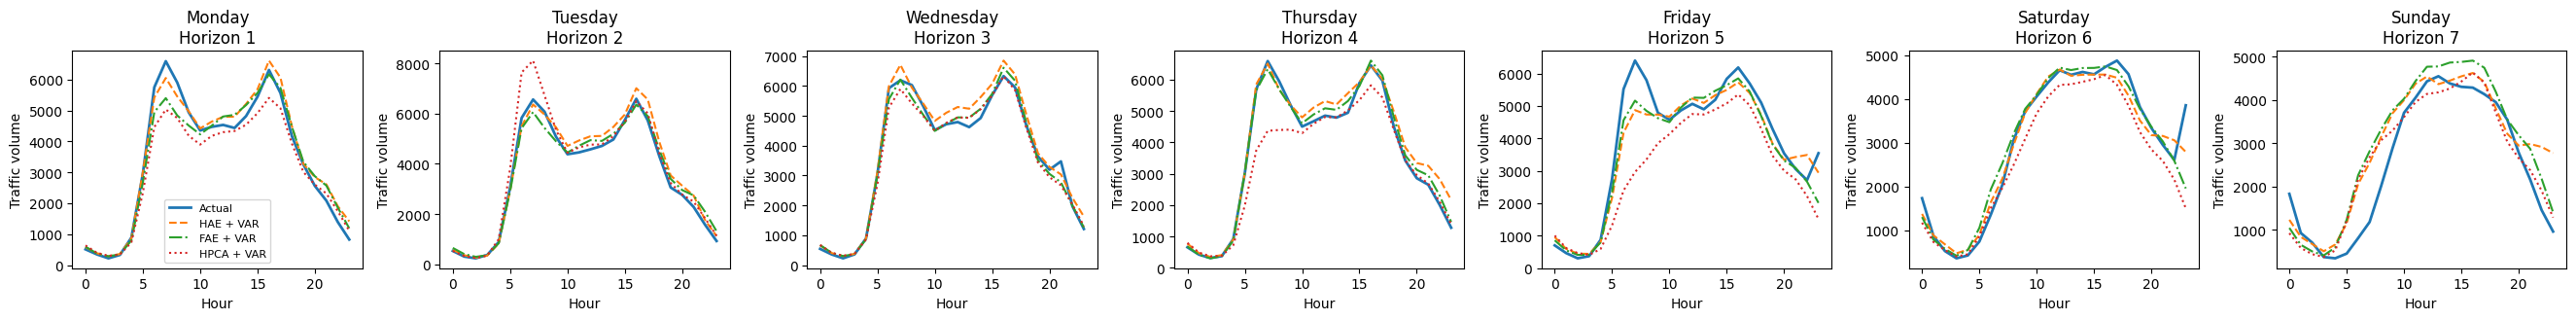


Functional count-scale MSE by horizon
 horizon  HAE_count_MSE  FAE_count_MSE  HPCA_count_MSE
       1  103024.974056  197072.108775   356725.517230
       2  134816.565391   90070.711943   299266.691947
       3  120272.609812   55090.016114    88447.329259
       4  151790.393519   38241.278205   581796.446630
       5  322945.117333  285254.007094  1629805.463339
       6   94733.079942  196138.165666   370376.162619
       7  546867.216156  495912.165812   339886.956870


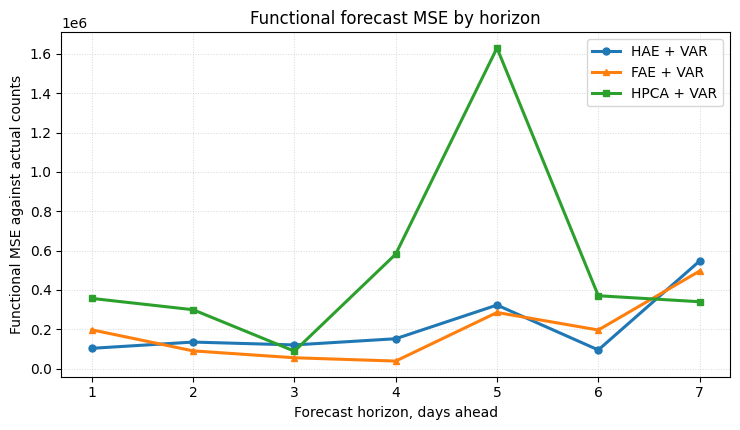

In [7]:
# ============================================================
# Run-after block:
# Recreate HAE + HPCA outputs, train FAE, compare all with actual
# ============================================================

# -----------------------------
# Recreate data and HAE/HPCA outputs
# -----------------------------

set_seed(CFG.seed)

device = torch.device("cpu")

print("\nReloading data for HAE / FAE / HPCA comparison...")
df_hour = load_hourly_traffic_dataframe(CFG)

s, x_counts, y_raw, y_feature_names, dates = build_daily_functional_and_nonfunctional_data(
    df_hour
)

if x_counts.shape[0] <= CFG.forecast_horizon + 65:
    raise ValueError("Not enough complete days for the requested forecast horizon.")

L = CFG.forecast_horizon

x_log = np.log1p(x_counts).astype(np.float32)

x_train_log_full = x_log[:-L]
x_test_counts = x_counts[-L:]

y_train_raw_full = y_raw[:-L]
y_test_raw = y_raw[-L:]

test_dates = dates[-L:]

x_log_scaler = StandardScaler()
x_train_standardized_log_full = x_log_scaler.fit_transform(
    x_train_log_full
).astype(np.float32)
x_test_standardized_log = x_log_scaler.transform(
    x_log[-L:]
).astype(np.float32)

y_scaler = StandardScaler()
y_train_scaled_full = y_scaler.fit_transform(
    y_train_raw_full
).astype(np.float32)
y_test_scaled = y_scaler.transform(
    y_test_raw
).astype(np.float32)

baseline_k = CFG.latent_dim if CFG.baseline_latent_dim is None else CFG.baseline_latent_dim

print("\nComparison setup")
print(f"Forecast/test observations:      {L}")
print(f"Forecast/test date range:        {test_dates[0].date()} to {test_dates[-1].date()}")
print(f"HAE latent dimension:            {CFG.latent_dim}")
print(f"HPCA score dimension:        {baseline_k}")


# -----------------------------
# Train HAE and forecast
# -----------------------------

hybrid_model, history, refit_history = train_one_tuned_hybrid_model(
    cfg=CFG,
    x_train_full=x_train_standardized_log_full,
    y_train_full=y_train_scaled_full,
    s=s,
    device=device,
)

(
    x_recon_train_hybrid,
    y_recon_train_hybrid_scaled,
    H_train_torch,
    _,
    hybrid_functional_recon_mse,
    hybrid_nonfunctional_recon_mse,
) = predict_hybrid_ae(
    hybrid_model,
    torch.tensor(x_train_standardized_log_full, dtype=torch.float32),
    torch.tensor(y_train_scaled_full, dtype=torch.float32),
    device,
)

H_train = H_train_torch.detach().cpu().numpy()

print("\nHAE reconstruction MSE on full pre-forecast block")
print(f"Functional standardized log1p-count scale: {hybrid_functional_recon_mse:.6f}")
print(f"Nonfunctional standardized scale:          {hybrid_nonfunctional_recon_mse:.6f}")

print("\nFitting external VAR model to HAE latent scores...")
H_forecast, hybrid_forecast_info, _ = forecast_scores_time_series(
    H_train,
    L,
    CFG.max_ar_lags,
)

print(
    f"HAE score model: "
    f"{hybrid_forecast_info['model']}({hybrid_forecast_info['lag']})"
)
print(f"HAE score AIC:   {hybrid_forecast_info['aic']:.6f}")

hybrid_model.eval()

with torch.no_grad():
    H_forecast_torch = torch.tensor(
        H_forecast,
        dtype=torch.float32,
    ).to(device)

    (
        x_hybrid_forecast_standardized_log_torch,
        _,
        y_hybrid_forecast_scaled_torch,
    ) = hybrid_model.decode_latent(H_forecast_torch)

    x_hybrid_forecast_standardized_log = (
        x_hybrid_forecast_standardized_log_torch
        .detach()
        .cpu()
        .numpy()
    )

    y_hybrid_forecast_scaled = (
        y_hybrid_forecast_scaled_torch
        .detach()
        .cpu()
        .numpy()
    )

x_hybrid_forecast_counts = inverse_standardized_log_count_transform(
    x_hybrid_forecast_standardized_log,
    x_log_scaler,
)


# -----------------------------
# Train HPCA baseline and forecast
# -----------------------------

print("\nFitting HPCA baseline...")

baseline_out = concatenated_fpca_pca_forecast(
    x_train_standardized_log=x_train_standardized_log_full,
    y_train_scaled=y_train_scaled_full,
    horizon=L,
    latent_dim=baseline_k,
    maxlags=CFG.max_ar_lags,
)

x_baseline_forecast_counts = inverse_standardized_log_count_transform(
    baseline_out["x_forecast_standardized_log"],
    x_log_scaler,
)

y_baseline_forecast_scaled = baseline_out["y_forecast_scaled"]

print(
    f"HPCA score model: "
    f"{baseline_out['forecast_info']['model']}({baseline_out['forecast_info']['lag']})"
)
print(f"HPCA score AIC:   {baseline_out['forecast_info']['aic']:.6f}")


# ============================================================
# Functional-only FAE
# ============================================================

class FunctionalOnlyFAEAE(nn.Module):
    """
    Functional-only FAE:
        x -> functional feature layer -> latent h -> coefficients -> x_hat
    No nonfunctional input and no nonfunctional decoder.
    """

    def __init__(
        self,
        n_grid: int,
        latent_dim: int,
        functional_feature_dim: int,
        hidden_width: int,
        n_basis: int,
        basis: torch.Tensor,
    ):
        super().__init__()

        self.functional_feature_layer = tuned_mlp([
            n_grid,
            hidden_width,
            hidden_width,
            functional_feature_dim,
        ])

        self.functional_feature_norm = nn.LayerNorm(functional_feature_dim)

        self.latent_encoder = tuned_mlp([
            functional_feature_dim,
            hidden_width,
            hidden_width,
            latent_dim,
        ])

        self.decoder_to_coef = tuned_mlp([
            latent_dim,
            hidden_width,
            hidden_width,
            n_basis,
        ])

        self.register_buffer("basis", basis)

    def encode(self, x_func: torch.Tensor) -> torch.Tensor:
        f = self.functional_feature_layer(x_func)
        f = self.functional_feature_norm(f)
        h = self.latent_encoder(f)
        return h

    def decode_latent(self, h: torch.Tensor):
        coef = self.decoder_to_coef(h)
        x_hat = torch.matmul(coef, self.basis)
        return x_hat, coef

    def forward(self, x_func: torch.Tensor):
        h = self.encode(x_func)
        x_hat, coef = self.decode_latent(h)
        return x_hat, h, coef


def build_fae_model(cfg, n_grid, s, device):
    basis = make_bspline_basis(s, cfg.n_basis)

    return FunctionalOnlyFAEAE(
        n_grid=n_grid,
        latent_dim=cfg.latent_dim,
        functional_feature_dim=cfg.functional_feature_dim,
        hidden_width=cfg.hidden_width,
        n_basis=cfg.n_basis,
        basis=basis,
    ).to(device)


def train_fae_simple(cfg, x_train_full, s, device):
    set_seed(cfg.seed + 1000)

    n_total = x_train_full.shape[0]
    n_val = int(round(cfg.validation_fraction * n_total))
    n_val = max(1, min(n_val, n_total - 1))

    x_train = x_train_full[:-n_val]
    x_val = x_train_full[-n_val:]

    model = build_fae_model(
        cfg=cfg,
        n_grid=x_train_full.shape[1],
        s=s,
        device=device,
    )

    train_loader = DataLoader(
        TensorDataset(torch.tensor(x_train, dtype=torch.float32)),
        batch_size=cfg.batch_size,
        shuffle=cfg.shuffle_batches,
        drop_last=False,
    )

    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    mse_loss = nn.MSELoss()

    best_state = None
    best_val = np.inf
    best_epoch = None
    bad_epochs = 0

    print("\nTraining functional-only FAE...")

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        train_loss_sum = 0.0
        n_seen = 0

        for (x_batch,) in train_loader:
            x_batch = x_batch.to(device)

            optimizer.zero_grad(set_to_none=True)

            x_hat, h, coef = model(x_batch)

            functional_recon = mse_loss(x_hat, x_batch)

            coef_second_diff = coef[:, 2:] - 2.0 * coef[:, 1:-1] + coef[:, :-2]
            coef_smooth_penalty = torch.mean(torch.sum(coef_second_diff ** 2, dim=1))

            if h.shape[0] >= 3 and cfg.latent_smooth_lambda > 0:
                latent_second_diff = h[2:, :] - 2.0 * h[1:-1, :] + h[:-2, :]
                latent_smooth_penalty = torch.mean(latent_second_diff ** 2)
            else:
                latent_smooth_penalty = torch.tensor(0.0, device=device)

            loss = (
                functional_recon
                + cfg.smooth_lambda * coef_smooth_penalty
                + cfg.latent_smooth_lambda * latent_smooth_penalty
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=cfg.gradient_clip_norm,
            )
            optimizer.step()

            bs = x_batch.shape[0]
            train_loss_sum += functional_recon.item() * bs
            n_seen += bs

        model.eval()
        with torch.no_grad():
            x_val_hat, _, _ = model(x_val_t)
            val_loss = mse_loss(x_val_hat, x_val_t).item()

        checkpoint_allowed = epoch >= cfg.checkpoint_start_epoch

        if checkpoint_allowed and val_loss < best_val - cfg.early_stopping_min_delta:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            bad_epochs = 0
        elif checkpoint_allowed:
            bad_epochs += 1

        if epoch == 1 or epoch % 50 == 0 or epoch == cfg.epochs:
            marker = "*" if checkpoint_allowed else " "
            print(
                f"FAE epoch {epoch:4d}/{cfg.epochs}{marker} | "
                f"train_func={train_loss_sum / n_seen:.6f} | "
                f"val_func={val_loss:.6f}"
            )

        if checkpoint_allowed and bad_epochs >= cfg.early_stopping_patience:
            print(
                f"FAE early stopping at epoch {epoch}. "
                f"Best epoch={best_epoch}, best val functional MSE={best_val:.6f}"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    if cfg.refit_final_on_full_preforecast:
        final_epochs = int(
            min(
                cfg.final_refit_max_epochs,
                max(
                    cfg.final_refit_min_epochs,
                    round((best_epoch or epoch) * cfg.final_refit_epoch_multiplier),
                ),
            )
        )

        print(
            "\nRefitting functional-only FAE on full pre-forecast block "
            f"for {final_epochs} epochs..."
        )

        set_seed(cfg.seed + 1000)

        model = build_fae_model(
            cfg=cfg,
            n_grid=x_train_full.shape[1],
            s=s,
            device=device,
        )

        full_loader = DataLoader(
            TensorDataset(torch.tensor(x_train_full, dtype=torch.float32)),
            batch_size=cfg.batch_size,
            shuffle=cfg.shuffle_batches,
            drop_last=False,
        )

        optimizer = optim.AdamW(
            model.parameters(),
            lr=cfg.learning_rate,
            weight_decay=cfg.weight_decay,
        )

        for epoch in range(1, final_epochs + 1):
            model.train()

            train_loss_sum = 0.0
            n_seen = 0

            for (x_batch,) in full_loader:
                x_batch = x_batch.to(device)

                optimizer.zero_grad(set_to_none=True)

                x_hat, h, coef = model(x_batch)

                functional_recon = mse_loss(x_hat, x_batch)

                coef_second_diff = coef[:, 2:] - 2.0 * coef[:, 1:-1] + coef[:, :-2]
                coef_smooth_penalty = torch.mean(torch.sum(coef_second_diff ** 2, dim=1))

                if h.shape[0] >= 3 and cfg.latent_smooth_lambda > 0:
                    latent_second_diff = h[2:, :] - 2.0 * h[1:-1, :] + h[:-2, :]
                    latent_smooth_penalty = torch.mean(latent_second_diff ** 2)
                else:
                    latent_smooth_penalty = torch.tensor(0.0, device=device)

                loss = (
                    functional_recon
                    + cfg.smooth_lambda * coef_smooth_penalty
                    + cfg.latent_smooth_lambda * latent_smooth_penalty
                )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=cfg.gradient_clip_norm,
                )
                optimizer.step()

                bs = x_batch.shape[0]
                train_loss_sum += functional_recon.item() * bs
                n_seen += bs

            if epoch == 1 or epoch % 50 == 0 or epoch == final_epochs:
                print(
                    f"Final FAE refit epoch {epoch:4d}/{final_epochs} | "
                    f"train_func={train_loss_sum / n_seen:.6f}"
                )

    return model


def forecast_fae_from_trained_model(
    fae_model,
    x_train_standardized_log_full,
    horizon,
    cfg,
    x_log_scaler,
    device,
):
    fae_model.eval()

    with torch.no_grad():
        x_train_t = torch.tensor(
            x_train_standardized_log_full,
            dtype=torch.float32,
        ).to(device)

        x_recon_t, H_train_fae_t, _ = fae_model(x_train_t)

        fae_recon_mse = torch.mean((x_recon_t - x_train_t) ** 2).item()

    H_train_fae = H_train_fae_t.detach().cpu().numpy()

    print("\nFunctional-only FAE reconstruction MSE on full pre-forecast block")
    print(f"Functional standardized log1p-count scale: {fae_recon_mse:.6f}")

    print("\nFitting external VAR model to functional-only FAE latent scores...")

    H_fae_forecast, fae_forecast_info, _ = forecast_scores_time_series(
        H_train_fae,
        horizon,
        cfg.max_ar_lags,
    )

    print(
        f"Functional-only FAE score model: "
        f"{fae_forecast_info['model']}({fae_forecast_info['lag']})"
    )
    print(f"Functional-only FAE score AIC:   {fae_forecast_info['aic']:.6f}")

    with torch.no_grad():
        H_fae_forecast_t = torch.tensor(
            H_fae_forecast,
            dtype=torch.float32,
        ).to(device)

        x_fae_forecast_standardized_log_t, _ = fae_model.decode_latent(
            H_fae_forecast_t
        )

        x_fae_forecast_standardized_log = (
            x_fae_forecast_standardized_log_t
            .detach()
            .cpu()
            .numpy()
        )

    x_fae_forecast_counts = inverse_standardized_log_count_transform(
        x_fae_forecast_standardized_log,
        x_log_scaler,
    )

    return x_fae_forecast_counts, x_fae_forecast_standardized_log


# -----------------------------
# Train FAE and forecast
# -----------------------------

fae_model = train_fae_simple(
    cfg=CFG,
    x_train_full=x_train_standardized_log_full,
    s=s,
    device=device,
)

x_fae_forecast_counts, x_fae_forecast_standardized_log = forecast_fae_from_trained_model(
    fae_model=fae_model,
    x_train_standardized_log_full=x_train_standardized_log_full,
    horizon=L,
    cfg=CFG,
    x_log_scaler=x_log_scaler,
    device=device,
)


# -----------------------------
# Comparison table
# -----------------------------

comparison = pd.DataFrame([
    {
        "Method": "HAE + VAR",
        "Functional_MSE_count": mse(x_hybrid_forecast_counts, x_test_counts),
        "Functional_RMSE_count": rmse(x_hybrid_forecast_counts, x_test_counts),
        "Functional_relMSE_count": relative_mse(x_hybrid_forecast_counts, x_test_counts),
        "Functional_MSE_stdlog": mse(x_hybrid_forecast_standardized_log, x_test_standardized_log),
    },
    {
        "Method": "FAE + VAR",
        "Functional_MSE_count": mse(x_fae_forecast_counts, x_test_counts),
        "Functional_RMSE_count": rmse(x_fae_forecast_counts, x_test_counts),
        "Functional_relMSE_count": relative_mse(x_fae_forecast_counts, x_test_counts),
        "Functional_MSE_stdlog": mse(x_fae_forecast_standardized_log, x_test_standardized_log),
    },
    {
        "Method": "HPCA + VAR",
        "Functional_MSE_count": mse(x_baseline_forecast_counts, x_test_counts),
        "Functional_RMSE_count": rmse(x_baseline_forecast_counts, x_test_counts),
        "Functional_relMSE_count": relative_mse(x_baseline_forecast_counts, x_test_counts),
        "Functional_MSE_stdlog": mse(baseline_out["x_forecast_standardized_log"], x_test_standardized_log),
    },
])

comparison = pd.DataFrame([
    {
        "Method": "HAE + VAR",
        "Functional_TOTAL_SE_count": np.sum((x_hybrid_forecast_counts - x_test_counts) ** 2),
        "Functional_MEAN_MSE_by_day": np.mean(np.mean((x_hybrid_forecast_counts - x_test_counts) ** 2, axis=1)),
        "Functional_MSE_count": mse(x_hybrid_forecast_counts, x_test_counts),
        "Functional_RMSE_count": rmse(x_hybrid_forecast_counts, x_test_counts),
        "Functional_relMSE_count": relative_mse(x_hybrid_forecast_counts, x_test_counts),
        "Functional_MSE_stdlog": mse(x_hybrid_forecast_standardized_log, x_test_standardized_log),
    },
    {
        "Method": "FAE + VAR",
        "Functional_TOTAL_SE_count": np.sum((x_fae_forecast_counts - x_test_counts) ** 2),
        "Functional_MEAN_MSE_by_day": np.mean(np.mean((x_fae_forecast_counts - x_test_counts) ** 2, axis=1)),
        "Functional_MSE_count": mse(x_fae_forecast_counts, x_test_counts),
        "Functional_RMSE_count": rmse(x_fae_forecast_counts, x_test_counts),
        "Functional_relMSE_count": relative_mse(x_fae_forecast_counts, x_test_counts),
        "Functional_MSE_stdlog": mse(x_fae_forecast_standardized_log, x_test_standardized_log),
    },
    {
        "Method": "HPCA + VAR",
        "Functional_TOTAL_SE_count": np.sum((x_baseline_forecast_counts - x_test_counts) ** 2),
        "Functional_MEAN_MSE_by_day": np.mean(np.mean((x_baseline_forecast_counts - x_test_counts) ** 2, axis=1)),
        "Functional_MSE_count": mse(x_baseline_forecast_counts, x_test_counts),
        "Functional_RMSE_count": rmse(x_baseline_forecast_counts, x_test_counts),
        "Functional_relMSE_count": relative_mse(x_baseline_forecast_counts, x_test_counts),
        "Functional_MSE_stdlog": mse(baseline_out["x_forecast_standardized_log"], x_test_standardized_log),
    },
])

print("\nFunctional forecast comparison: HAE vs FAE vs HPCA")
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.6f}"))


# -----------------------------
# Forecast curve plot
# -----------------------------

n_plot = x_test_counts.shape[0]

plt.figure(figsize=(3.8 * n_plot, 3.4))

for i in range(n_plot):
    ax = plt.subplot(1, n_plot, i + 1)

    ax.plot(
        s,
        x_test_counts[i],
        label="Actual",
        linewidth=2,
    )

    ax.plot(
        s,
        x_hybrid_forecast_counts[i],
        linestyle="--",
        label="HAE + VAR",
    )

    ax.plot(
        s,
        x_fae_forecast_counts[i],
        linestyle="-.",
        label="FAE + VAR",
    )

    ax.plot(
        s,
        x_baseline_forecast_counts[i],
        linestyle=":",
        label="HPCA + VAR",
    )

    day_name = pd.Timestamp(test_dates[i]).day_name()
    ax.set_title(f"{day_name}\nHorizon {i + 1}")

    ax.set_xlabel("Hour")
    ax.set_ylabel("Traffic volume")

    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# -----------------------------
# Functional MSE by horizon plot
# -----------------------------

hae_h = np.mean((x_hybrid_forecast_counts - x_test_counts) ** 2, axis=1)
fae_h = np.mean((x_fae_forecast_counts - x_test_counts) ** 2, axis=1)
hpca_h = np.mean((x_baseline_forecast_counts - x_test_counts) ** 2, axis=1)

horizon = np.arange(1, len(hae_h) + 1)

horizon_table = pd.DataFrame({
    "horizon": horizon,
    "HAE_count_MSE": hae_h,
    "FAE_count_MSE": fae_h,
    "HPCA_count_MSE": hpca_h,
})

print("\nFunctional count-scale MSE by horizon")
print(horizon_table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

plt.figure(figsize=(7.5, 4.4))

plt.plot(
    horizon,
    hae_h,
    marker="o",
    markersize=5,
    linewidth=2.2,
    label="HAE + VAR",
)

plt.plot(
    horizon,
    fae_h,
    marker="^",
    markersize=5,
    linewidth=2.2,
    label="FAE + VAR",
)

plt.plot(
    horizon,
    hpca_h,
    marker="s",
    markersize=5,
    linewidth=2.2,
    label="HPCA + VAR",
)

plt.xticks(horizon)
plt.xlabel("Forecast horizon, days ahead")
plt.ylabel("Functional MSE against actual counts")
plt.title("Functional forecast MSE by horizon")
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()